In [1]:
import random
import torch
import os
import math

import matplotlib.pyplot as plt

from collections import defaultdict

from causal_gym import HumanoidMazePCH
from causal_rl.algo.imitation.imitate import *
from causal_rl.algo.imitation.finetune import *
from causal_rl.algo.imitation.gail.core_net import *
from causal_rl.algo.imitation.gail.causal_gail import *

<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/home/et2842/miniconda3/envs/causalenv/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Train expert base

In [3]:
num_steps = 1000
seed = 0
hidden_dims = {'W'}

random.seed(seed)
torch.manual_seed(seed)

In [4]:
env = HumanoidMazePCH(env_id='humanoidmaze-medium-navigate-singletask-task1-v0', num_steps=num_steps, expert_mode=True, custom_hidden=hidden_dims, seed=seed)
train_eps = env.expert.num_eps
train_eps

2200

In [5]:
X = {f'X{t}' for t in range(num_steps)}
Y = f'Y{num_steps}'
obs_prefix = env.env.observed_unobserved_vars[0]

In [6]:
Z_sets = {}
for Xi in X:
    i = int(Xi[1:])
    cond = set()

    for j in range(i+1):
        cond.update({f'{o}{j}' for o in list(set(obs_prefix) - {'X'})})

    for j in range(i):
        cond.add(f'X{j}')

    Z_sets[Xi] = cond

In [7]:
records = collect_expert_trajectories(
    env,
    num_episodes=train_eps,
    max_steps=num_steps,
    seed=seed
)

In [8]:
# Initial expert BC training parameters
hidden_size = 256
lr = 3e-4
batch_size = 2048
patience = 20          # FIXED: increased from 15 to allow more training
lookback = 1
num_blocks = 4
epochs = 200           # FIXED: increased from 100 to train longer
dropout = 0.0

dims = {
    'P': 2,
    'A': 21,
    'H': 1,
    'E': 12,
    'V': 3,
    'C': 3,
    'J': 27,
    'X': 21
}

In [9]:
model, slots, Z_trim = train_single_policy_long_horizon(
    records,
    Z_sets,
    dims=dims,
    epochs=epochs,
    include_vars=obs_prefix,
    lookback=lookback,
    continuous=True,
    num_actions = env.action_space.shape[0],
    hidden_dim=hidden_size,
    num_blocks=num_blocks,
    dropout=dropout,
    lr=lr,
    batch_size=batch_size,
    patience=patience,
    device=device,
    seed=seed,
    action_bounds=(env.action_space.low, env.action_space.high)
)

policy = shared_policy_fn_long_horizon(model, slots, Z_trim, continuous=True, device=device)
policies = make_shared_policy_dict(policy)

[LongHorizon] Epoch 1: train loss = 0.084400, val loss = 0.070429.


[LongHorizon] Epoch 2: train loss = 0.067635, val loss = 0.065654.


[LongHorizon] Epoch 3: train loss = 0.063689, val loss = 0.062377.


[LongHorizon] Epoch 4: train loss = 0.060955, val loss = 0.060228.


[LongHorizon] Epoch 5: train loss = 0.058887, val loss = 0.058221.


...

[LongHorizon] Epoch 196: train loss = 0.037973, val loss = 0.040530.


[LongHorizon] Epoch 197: train loss = 0.037958, val loss = 0.040496.


[LongHorizon] Epoch 198: train loss = 0.037956, val loss = 0.040529.


[LongHorizon] Epoch 199: train loss = 0.037934, val loss = 0.040554.


[LongHorizon] Epoch 200: train loss = 0.037913, val loss = 0.040609.


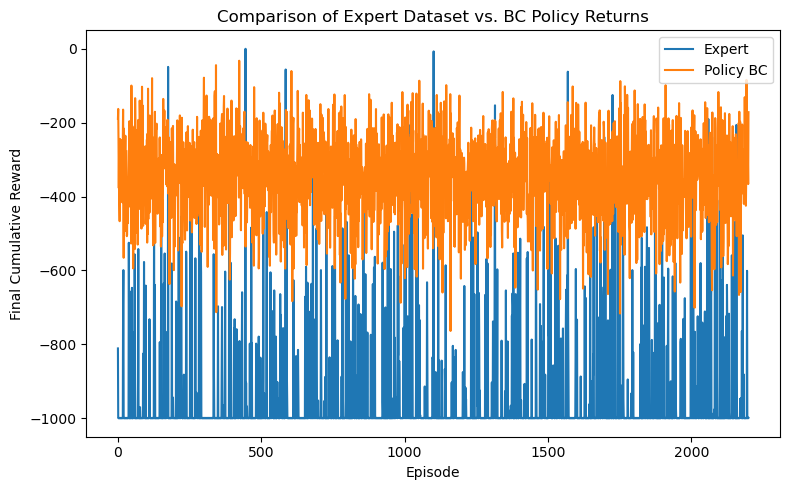

In [10]:
expert_episode_rewards = defaultdict(float)
for rec in records:
    ep = rec['episode']
    expert_episode_rewards[ep] += float(rec['reward'])

num_eps = len(expert_episode_rewards)
expert_rewards = [expert_episode_rewards[e] for e in range(num_eps)]

policy_records = collect_imitator_trajectories(env, policies, num_episodes=num_eps, max_steps=num_steps, seed=seed)
policy_episode_rewards = defaultdict(float)
for rec in policy_records:
    ep = rec['episode']
    policy_episode_rewards[ep] += float(rec['reward'])

policy_rewards = [policy_episode_rewards[e] for e in range(num_eps)]
plt.figure(figsize=(8,5))
plt.plot(expert_rewards, label='Expert')
plt.plot(policy_rewards, label='Policy BC')
plt.xlabel('Episode')
plt.ylabel('Final Cumulative Reward')
plt.title('Comparison of Expert Dataset vs. BC Policy Returns')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
sum(expert_rewards)/num_eps, sum(policy_rewards)/num_eps

(-939.5436363636363, -343.93197284538064)

In [12]:
# save model for fine-tuning
import os
import torch

SAVE_DIR = '/home/et2842/causal/causalrl/models'
os.makedirs(SAVE_DIR, exist_ok=True)
MODEL_PATH = os.path.join(SAVE_DIR, 'humanoidmaze_medium_expert.pt')

checkpoint = {
    "state_dict": model.state_dict(),
    "slots": slots,
    "Z_trim": Z_trim,
    "dims": dims,
    "lookback": lookback,
    "continuous": True,
    "num_actions": env.action_space.shape[0],
    "hidden_dim": hidden_size,
    "num_blocks": num_blocks,
    "dropout": 0.0,
    "layernorm": True,
    "final_tanh": True,
    "action_bounds_low": env.action_space.low,
    "action_bounds_high": env.action_space.high,
    "input_dim": int(model.hidden.in_features),
}

torch.save(checkpoint, MODEL_PATH)
print("Saved expert to:", MODEL_PATH)

Saved expert to: /home/et2842/causal/causalrl/models/humanoidmaze_medium_expert.pt


# Fine-tune expert

In [13]:
# load model
MODEL_PATH = "/home/et2842/causal/causalrl/models/humanoidmaze_medium_expert.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

# Rebuild the model with the same architecture
action_bounds = (checkpoint['action_bounds_low'], checkpoint['action_bounds_high'])

pretrained_actor = ContinuousPolicyNN(
    input_dim=checkpoint['input_dim'],
    action_dim=checkpoint['num_actions'],
    hidden_dim=checkpoint['hidden_dim'],
    num_blocks=checkpoint['num_blocks'],
    dropout=checkpoint['dropout'],
    layernorm=checkpoint['layernorm'],
    final_tanh=checkpoint['final_tanh'],
    action_bounds=action_bounds,
).to(device)

pretrained_actor.load_state_dict(checkpoint['state_dict'])
# pretrained_actor.eval()
pretrained_actor.train()

slots = checkpoint['slots']
Z_trim = checkpoint['Z_trim']
dims = checkpoint['dims']
lookback = checkpoint['lookback']

state_dim = checkpoint['input_dim']
state_dim

/tmp/ipykernel_317685/3591495865.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=device)


98

In [14]:
num_steps = 1000
rl_seed_pretrain = 2014
rl_seed = 90210
hidden_dims = set() # {'W'}

env_pretrain = HumanoidMazePCH(env_id='humanoidmaze-medium-navigate-singletask-task1-v0', num_steps=num_steps, expert_mode=True, seed=rl_seed_pretrain)
env_train = HumanoidMazePCH(env_id='humanoidmaze-medium-navigate-singletask-task1-v0', num_steps=num_steps, expert_mode=True, seed=rl_seed)
action_dim = env_train.env.action_space.shape[0]
action_dim

21

In [15]:
# reward shaping
def make_dense_distance_reward(env, use_delta=True, c=1.0):
        goal_xy = env.env._goal_xy
    
        def reward_fn(obs, reward_env):
            t = len(obs['P']) - 1
    
            P_curr = obs['P'][t]
            curr_xy = np.array(P_curr[:2], dtype=np.float64)
            dist_curr = np.linalg.norm(curr_xy - goal_xy)
    
            if use_delta:
                if t == 0:
                    return 0.0
                P_prev = obs['P'][t - 1]
                prev_xy = np.array(P_prev[:2], dtype=np.float64)
                dist_prev = np.linalg.norm(prev_xy - goal_xy)
                return float(c * (dist_prev - dist_curr))
            else:
                return float(-c * dist_curr)
    
        return reward_fn

reward_fn = make_dense_distance_reward(env_train)

In [16]:
# TD3 fine-tuning config - SIGNIFICANTLY INCREASED for HumanoidMaze
config = OnlineRLConfig(
    total_env_steps=2_000_000,      # FIXED: increased from 200k to 2M (10x more)
    start_steps=25_000,             # FIXED: increased from 10k for better exploration
    max_episode_steps=num_steps,
    batch_size=512,                 # FIXED: increased from 256 for stability
    gamma=0.99,
    tau=0.005,
    policy_delay=2,
    actor_lr=1e-5,                  # FIXED: increased from 3e-6 for faster learning
    critic_lr=3e-4,
    noise_std=0.1,                  # FIXED: increased from 0.05 for more exploration
    hidden_dim_q=512,               # FIXED: increased from 256 for higher capacity
    target_policy_noise=0.2,        # FIXED: increased from 0.1
    target_noise_clip=0.5,          # FIXED: increased from 0.2
    actor_warmup_steps=50_000,      # FIXED: increased from 30k
    bc_reg_lambda=0.05,             # FIXED: reduced from 0.1 to allow more RL learning
    max_grad_norm=1.0
)

In [17]:
# pretrain critics offline - SIGNIFICANTLY INCREASED
replay_buffer, q1, q2, target_q1, target_q2 = pretrain_critics_offline(
    env=env_pretrain,
    pretrained_actor=pretrained_actor,
    Z_trim=Z_trim,
    slots=slots,
    state_dim=state_dim,
    action_dim=action_dim,
    config=config,
    device=device,
    num_pretrain_steps=500_000,     # FIXED: increased from 100k to 500k (5x more data)
    pretrain_updates=200_000,       # FIXED: increased from 50k to 200k (4x more updates)
    seed=rl_seed_pretrain,
    reward_shaping_fn=reward_fn
)

In [18]:
def callback(stats: dict):
    if stats['episode'] % 1 == 0:
        print(
            f'[Episode {stats["episode"]}] '
            f'steps={stats["env_steps"]}, '
            f'return={stats["return"]:.2f}, '
            f'len={stats["length"]}, '
            f'buffer={stats["buffer_size"]}'
        )

In [19]:
fine_tuned_policy, logs = td3_fine_tune_actor(
    env=env_train,
    actor=pretrained_actor,
    Z_trim=Z_trim,
    slots=slots,
    state_dim=state_dim,
    action_dim=action_dim,
    config=config,
    device=device,
    seed=rl_seed,
    log_callback=callback,
    replay_buffer=replay_buffer,
    initial_q1=q1,
    initial_q2=q2,
    initial_target_q1=target_q1,
    initial_target_q2=target_q2,
    reward_shaping_fn=reward_fn
)

ft_pi = shared_policy_fn_long_horizon(fine_tuned_policy, slots, Z_trim, continuous=True, device=device)
ft_policies = make_shared_policy_dict(ft_pi)

[Episode 1] steps=1000, return=-1.92, len=1000, buffer=501865


[Episode 2] steps=2000, return=5.73, len=1000, buffer=502865


[Episode 3] steps=3000, return=6.54, len=1000, buffer=503865


[Episode 4] steps=4000, return=10.17, len=1000, buffer=504865


[Episode 5] steps=5000, return=5.15, len=1000, buffer=505865


...

[Episode 1996] steps=1996000, return=0.11, len=1000, buffer=1000000


[Episode 1997] steps=1997000, return=0.15, len=1000, buffer=1000000


[Episode 1998] steps=1998000, return=0.20, len=1000, buffer=1000000


[Episode 1999] steps=1999000, return=-0.27, len=1000, buffer=1000000


[Episode 2000] steps=2000000, return=-0.19, len=1000, buffer=1000000


In [20]:
# save expert
import os
import torch

SAVE_DIR = '/home/et2842/causal/causalrl/models'
os.makedirs(SAVE_DIR, exist_ok=True)
MODEL_PATH = os.path.join(SAVE_DIR, 'humanoidmaze_medium_expert_finetuned.pt')

checkpoint = {
    "state_dict": fine_tuned_policy.state_dict(),
    "slots": slots,
    "Z_trim": Z_trim,
    "dims": dims,
    "lookback": lookback,
    "continuous": True,
    "num_actions": env_train.action_space.shape[0],
    "hidden_dim": hidden_size,
    "num_blocks": num_blocks,
    "dropout": 0.0,
    "layernorm": True,
    "final_tanh": True,
    "action_bounds_low": env_train.action_space.low,
    "action_bounds_high": env_train.action_space.high,
    "input_dim": int(fine_tuned_policy.hidden.in_features),
}

torch.save(checkpoint, MODEL_PATH)
print("Saved expert to:", MODEL_PATH)

Saved expert to: /home/et2842/causal/causalrl/models/humanoidmaze_medium_expert_finetuned.pt


# Test BC

In [21]:
# BC training setup
num_steps = 1000
seed = 0
lookback = 1
hidden_dims = {'V'}
train_eps = 2000       # FIXED: increased from 1000 to 2000 for more expert data

random.seed(seed)
torch.manual_seed(seed)

In [22]:
expert_env = HumanoidMazePCH(env_id='humanoidmaze-medium-navigate-singletask-task1-v0', num_steps=num_steps, expert_mode=True, seed=seed)

In [23]:
env = HumanoidMazePCH(env_id='humanoidmaze-medium-navigate-singletask-task1-v0', num_steps=num_steps, seed=seed)

In [24]:
# to save time; conceptually the same
small_steps = lookback + 1
small_env = HumanoidMazePCH(env_id='humanoidmaze-medium-navigate-singletask-task1-v0', num_steps=small_steps, seed=seed)
G = parse_graph(small_env.get_graph)
X_small = {f'X{t}' for t in range(small_steps)}
Y = f'Y{small_steps}'

# G = parse_graph(env.get_graph)
X = {f'X{t}' for t in range(num_steps)}
# Y = f'Y{num_steps}'
obs_prefix = env.env.observed_unobserved_vars[0]

In [25]:
Z_sets = find_sequential_pi_backdoor(G, X_small, Y, obs_prefix)

base_step = small_steps - 1
base_Z_set = Z_sets[f'X{base_step}']

for i in range(base_step + 1, num_steps):
    updated_base_Z_set = set()
    for v in base_Z_set:
        updated_base_Z_set.add(f'{v[0]}{int(v[1:]) + i - lookback}')

    Z_sets[f'X{i}'] = updated_base_Z_set

Z_sets['X1']

{'A0', 'A1', 'C0', 'C1', 'E0', 'E1', 'H0', 'H1', 'J0', 'J1', 'P0', 'P1', 'X0'}

In [26]:
naive_Z_sets = {}
for Xi in X:
    i = int(Xi[1:])
    cond = set()

    for j in range(i+1):
        cond.update({f'{o}{j}' for o in list(set(obs_prefix) - {'X'})})

    for j in range(i):
        cond.add(f'X{j}')
    naive_Z_sets[Xi] = cond

naive_Z_sets['X1']

{'A0',
 'A1',
 'C0',
 'C1',
 'E0',
 'E1',
 'H0',
 'H1',
 'J0',
 'J1',
 'P0',
 'P1',
 'W0',
 'W1',
 'X0'}

In [27]:
# load expert
MODEL_PATH = '/home/et2842/causal/causalrl/models/humanoidmaze_medium_expert_finetuned.pt'
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)

# Rebuild the model with the same architecture
action_bounds = (checkpoint['action_bounds_low'], checkpoint['action_bounds_high'])

expert = ContinuousPolicyNN(
    input_dim=checkpoint['input_dim'],
    action_dim=checkpoint['num_actions'],
    hidden_dim=checkpoint['hidden_dim'],
    num_blocks=checkpoint['num_blocks'],
    dropout=checkpoint['dropout'],
    layernorm=checkpoint['layernorm'],
    final_tanh=checkpoint['final_tanh'],
    action_bounds=action_bounds,
).to(device)

expert.load_state_dict(checkpoint['state_dict'])
expert.eval()

slots = checkpoint['slots']
Z_trim = checkpoint['Z_trim']
dims = checkpoint['dims']
lookback = checkpoint['lookback']

state_dim = checkpoint['input_dim']
state_dim

expert_policy = shared_policy_fn_long_horizon(expert, slots, Z_trim, continuous=True, device=device)
expert_policies = make_shared_policy_dict(expert_policy)

In [28]:
records = collect_imitator_trajectories(
    expert_env,
    expert_policies,
    num_episodes=train_eps,
    max_steps=num_steps,
    seed=seed,
    hidden_dims=hidden_dims,
    show_progress=True
)

Starting episode 1/2000...


  Episode 1 ended at step 1000 (terminated: False, truncated: True).
Starting episode 2/2000...


  Episode 2 ended at step 1000 (terminated: False, truncated: True).
Starting episode 3/2000...


  Episode 3 ended at step 1000 (terminated: False, truncated: True).
Starting episode 4/2000...


  Episode 4 ended at step 1000 (terminated: False, truncated: True).
Starting episode 5/2000...


...

  Episode 1996 ended at step 1000 (terminated: False, truncated: True).
Starting episode 1997/2000...


  Episode 1997 ended at step 1000 (terminated: False, truncated: True).
Starting episode 1998/2000...


  Episode 1998 ended at step 1000 (terminated: False, truncated: True).
Starting episode 1999/2000...


  Episode 1999 ended at step 1000 (terminated: False, truncated: True).
Starting episode 2000/2000...


  Episode 2000 ended at step 1000 (terminated: False, truncated: True).
Finished collecting imitator trajectories.


In [29]:
# BC training hyperparameters
hidden_size = 256
lr = 3e-4
batch_size = 2048
patience = 20          # FIXED: increased from 15
num_blocks = 4
epochs = 200           # FIXED: increased from 100
dropout = 0.0

dims = {
    'P': 2,
    'A': 21,
    'H': 1,
    'E': 12,
    # 'V': 3,
    'C': 3,
    'J': 27,
    'W': 2,
    'X': 21
}

In [30]:
causal_model, causal_slots, causal_Z_trim = train_single_policy_long_horizon(
    records,
    Z_sets,
    dims=dims,
    epochs=epochs,
    include_vars=obs_prefix,
    lookback=lookback,
    continuous=True,
    num_actions = env.action_space.shape[0],
    hidden_dim=hidden_size,
    num_blocks=num_blocks,
    dropout=dropout,
    lr=lr,
    batch_size=batch_size,
    patience=patience,
    device=device,
    seed=seed,
    action_bounds=(env.action_space.low, env.action_space.high)
)

causal_policy = shared_policy_fn_long_horizon(causal_model, causal_slots, causal_Z_trim, continuous=True, device=device)
causal_policies = make_shared_policy_dict(causal_policy)

[LongHorizon] Epoch 1: train loss = 0.030118, val loss = 0.017277.


[LongHorizon] Epoch 2: train loss = 0.014379, val loss = 0.015456.


[LongHorizon] Epoch 3: train loss = 0.012405, val loss = 0.012949.


[LongHorizon] Epoch 4: train loss = 0.011196, val loss = 0.012209.


[LongHorizon] Epoch 5: train loss = 0.010342, val loss = 0.011460.


...

[LongHorizon] Epoch 79: train loss = 0.003599, val loss = 0.004784.


[LongHorizon] Epoch 80: train loss = 0.003578, val loss = 0.005163.


[LongHorizon] Epoch 81: train loss = 0.003561, val loss = 0.004781.


[LongHorizon] Epoch 82: train loss = 0.003538, val loss = 0.005193.


[LongHorizon] Early stop at epoch 83; best val 0.004512.


In [31]:
naive_model, naive_slots, naive_Z_trim = train_single_policy_long_horizon(
    records,
    naive_Z_sets,
    dims=dims,
    epochs=epochs,
    include_vars=obs_prefix,
    lookback=lookback,
    continuous=True,
    num_actions = env.action_space.shape[0],
    hidden_dim=hidden_size,
    num_blocks=num_blocks,
    dropout=dropout,
    lr=lr,
    batch_size=batch_size,
    patience=patience,
    device=device,
    seed=seed,
    action_bounds=(env.action_space.low, env.action_space.high)
)

naive_policy = shared_policy_fn_long_horizon(naive_model, naive_slots, naive_Z_trim, continuous=True, device=device)
naive_policies = make_shared_policy_dict(naive_policy)

[LongHorizon] Epoch 1: train loss = 0.030016, val loss = 0.017369.


[LongHorizon] Epoch 2: train loss = 0.014313, val loss = 0.015296.


[LongHorizon] Epoch 3: train loss = 0.012319, val loss = 0.012719.


[LongHorizon] Epoch 4: train loss = 0.011099, val loss = 0.012175.


[LongHorizon] Epoch 5: train loss = 0.010243, val loss = 0.011305.


...

[LongHorizon] Epoch 79: train loss = 0.003481, val loss = 0.004444.


[LongHorizon] Epoch 80: train loss = 0.003446, val loss = 0.004515.


[LongHorizon] Epoch 81: train loss = 0.003426, val loss = 0.004453.


[LongHorizon] Epoch 82: train loss = 0.003407, val loss = 0.004660.


[LongHorizon] Early stop at epoch 83; best val 0.004347.


In [32]:
SAVE_DIR = '/home/et2842/causal/causalrl/models'
os.makedirs(SAVE_DIR, exist_ok=True)
MODEL_PATH = os.path.join(SAVE_DIR, 'humanoidmaze_medium_causal_bc.pt')

checkpoint = {
    "state_dict": causal_model.state_dict(),
    "slots": causal_slots,
    "Z_trim": causal_Z_trim,
    "dims": dims,
    "lookback": lookback,
    "continuous": True,
    "num_actions": env.action_space.shape[0],
    "hidden_dim": hidden_size,
    "num_blocks": num_blocks,
    "dropout": 0.0,
    "layernorm": True,
    "final_tanh": True,
    "action_bounds_low": env.action_space.low,
    "action_bounds_high": env.action_space.high,
    "input_dim": int(causal_model.hidden.in_features),
}

torch.save(checkpoint, MODEL_PATH)
print("Saved expert to:", MODEL_PATH)

Saved expert to: /home/et2842/causal/causalrl/models/humanoidmaze_medium_causal_bc.pt


In [33]:
SAVE_DIR = '/home/et2842/causal/causalrl/models'
os.makedirs(SAVE_DIR, exist_ok=True)
MODEL_PATH = os.path.join(SAVE_DIR, 'humanoidmaze_medium_naive_bc.pt')

checkpoint = {
    "state_dict": naive_model.state_dict(),
    "slots": naive_slots,
    "Z_trim": naive_Z_trim,
    "dims": dims,
    "lookback": lookback,
    "continuous": True,
    "num_actions": env.action_space.shape[0],
    "hidden_dim": hidden_size,
    "num_blocks": num_blocks,
    "dropout": 0.0,
    "layernorm": True,
    "final_tanh": True,
    "action_bounds_low": env.action_space.low,
    "action_bounds_high": env.action_space.high,
    "input_dim": int(naive_model.hidden.in_features),
}

torch.save(checkpoint, MODEL_PATH)
print("Saved expert to:", MODEL_PATH)

Saved expert to: /home/et2842/causal/causalrl/models/humanoidmaze_medium_naive_bc.pt


# Test GAIL

In [34]:
# GAIL training setup
num_steps = 1000
seed = 0
lookback = 1
hidden_dims = {'V'}
train_eps = 500        # FIXED: increased from 300 to 500 for more expert data

random.seed(seed)
torch.manual_seed(seed)

In [35]:
expert_env = HumanoidMazePCH(env_id='humanoidmaze-medium-navigate-singletask-task1-v0', num_steps=num_steps, expert_mode=True, seed=seed)

In [36]:
env = HumanoidMazePCH(env_id='humanoidmaze-medium-navigate-singletask-task1-v0', num_steps=num_steps, seed=seed)

In [37]:
# to save time; conceptually the same
small_steps = lookback + 1
small_env = HumanoidMazePCH(env_id='humanoidmaze-medium-navigate-singletask-task1-v0', num_steps=small_steps, seed=seed)
G = parse_graph(small_env.get_graph)
X_small = {f'X{t}' for t in range(small_steps)}
Y = f'Y{small_steps}'

# G = parse_graph(env.get_graph)
X = {f'X{t}' for t in range(num_steps)}
# Y = f'Y{num_steps}'
obs_prefix = env.env.observed_unobserved_vars[0]

In [38]:
Z_sets = find_sequential_pi_backdoor(G, X_small, Y, obs_prefix)

base_step = small_steps - 1
base_Z_set = Z_sets[f'X{base_step}']

for i in range(base_step + 1, num_steps):
    updated_base_Z_set = set()
    for v in base_Z_set:
        updated_base_Z_set.add(f'{v[0]}{int(v[1:]) + i - lookback}')

    Z_sets[f'X{i}'] = updated_base_Z_set

Z_sets['X1']

{'A0', 'A1', 'C0', 'C1', 'E0', 'E1', 'H0', 'H1', 'J0', 'J1', 'P0', 'P1', 'X0'}

In [39]:
naive_Z_sets = {}
for Xi in X:
    i = int(Xi[1:])
    cond = set()

    for j in range(i+1):
        cond.update({f'{o}{j}' for o in list(set(obs_prefix) - {'X'})})

    for j in range(i):
        cond.add(f'X{j}')
    naive_Z_sets[Xi] = cond

naive_Z_sets['X1']

{'A0',
 'A1',
 'C0',
 'C1',
 'E0',
 'E1',
 'H0',
 'H1',
 'J0',
 'J1',
 'P0',
 'P1',
 'W0',
 'W1',
 'X0'}

In [40]:
dims = {
    'P': 2,
    'A': 21,
    'H': 1,
    'E': 12,
    # 'V': 3,
    'C': 3,
    'J': 27,
    'W': 2,
    'X': 21
}

In [41]:
sample_obs = records[0]['obs']

# Trim Z-sets to the lookback window (this matches what you do for BC)
causal_Z_trim = trim_Z_sets(Z_sets, lookback=lookback)
naive_Z_trim  = trim_Z_sets(naive_Z_sets, lookback=lookback)

# Build windowed encoders that depend on relative lags (not absolute time)
causal_encode, causal_z_dim, causal_slots = build_windowed_z_encoder(
    causal_Z_trim,
    dims=dims,
    lookback=lookback,
)
naive_encode, naive_z_dim, naive_slots = build_windowed_z_encoder(
    naive_Z_trim,
    dims=dims,
    lookback=lookback,
)

causal_z_dim, naive_z_dim

(153, 157)

In [42]:
# precompute expert batches once (so one_training_round doesn't redo this every time)
Z_e_causal, A_e_causal, X_e_causal = make_expert_batch(records, causal_encode)
X_e_causal = X_e_causal.to(device)

Z_e_naive, A_e_naive, X_e_naive = make_expert_batch(records, naive_encode)
X_e_naive = X_e_naive.to(device)

In [43]:
# PPO hyperparameters
gail_gamma          = 0.99
gae_lambda          = 0.95
ppo_clip            = 0.2
ppo_epochs          = 10
ppo_minibatch_size  = 1024
entropy_coeff       = 1e-3          # FIXED: increased from 5e-4 for more exploration
value_coeff         = 0.5
max_grad_norm       = 0.5
normalize_adv       = True

# discriminator - with regularization to prevent collapse
d_loss_type         = 'bce'
gp_lambda           = 10.0
d_updates           = 1             # FIXED: reduced from 3 to slow discriminator
d_minibatch_size    = 1024
use_gp              = True          # FIXED: enabled gradient penalty
instance_noise_std  = 0.1           # FIXED: added instance noise
label_smoothing     = 0.1           # FIXED: added label smoothing

# rollout - increased training
max_steps_per_episode   = num_steps
episodes_per_round      = 20        # FIXED: increased from 10 for more data per round
num_rounds_causal_gail  = 500       # FIXED: increased from 300 to 500
num_rounds_naive_gail   = 500       # FIXED: increased from 300 to 500

# network architecture
hidden_size_actor   = 256
hidden_size_critic  = 256
hidden_size_disc    = 128           # FIXED: reduced from 256 to limit discriminator capacity
actor_lr            = 1e-4
critic_lr           = 3e-4
disc_lr             = 5e-5          # FIXED: reduced from 3e-4 to slow discriminator
num_blocks_actor    = 3
dropout_actor       = 0.05
layernorm_actor     = True

In [44]:
action_dim = env.env.action_space.shape[0]
action_low = float(env.env.action_space.low.min())
action_high = float(env.env.action_space.high.max())

causal_actor = ContinuousActor(
    num_inputs=causal_z_dim,
    num_outputs=action_dim,
    hidden_size=hidden_size_actor,
    std=0.0,
    action_low=action_low,
    action_high=action_high,
    num_blocks=num_blocks_actor,
    dropout=dropout_actor,
    layernorm=layernorm_actor,
).to(device)

causal_critic = Critic(
    num_inputs=causal_z_dim,
    hidden_size=hidden_size_critic,
).to(device)

causal_disc = Discriminator(
    num_inputs=causal_z_dim + action_dim,
    hidden_size=hidden_size_disc,
    dropout=0.5,  # FIXED: increased from 0.2 to 0.5 for stronger regularization
).to(device)

actor_optim_causal = torch.optim.Adam(causal_actor.parameters(), lr=actor_lr)
critic_optim_causal = torch.optim.Adam(causal_critic.parameters(), lr=critic_lr)
disc_optim_causal = torch.optim.Adam(causal_disc.parameters(), lr=disc_lr)

In [45]:
naive_actor = ContinuousActor(
    num_inputs=naive_z_dim,
    num_outputs=action_dim,
    hidden_size=hidden_size_actor,
    std=0.0,
    action_low=action_low,
    action_high=action_high,
    num_blocks=num_blocks_actor,
    dropout=dropout_actor,
    layernorm=layernorm_actor,
).to(device)

naive_critic = Critic(
    num_inputs=naive_z_dim,
    hidden_size=hidden_size_critic,
).to(device)

naive_disc = Discriminator(
    num_inputs=naive_z_dim + action_dim,
    hidden_size=hidden_size_disc,
    dropout=0.5,  # FIXED: increased from 0.2 to 0.5 for stronger regularization
).to(device)

actor_optim_naive = torch.optim.Adam(naive_actor.parameters(), lr=actor_lr)
critic_optim_naive = torch.optim.Adam(naive_critic.parameters(), lr=critic_lr)
disc_optim_naive = torch.optim.Adam(naive_disc.parameters(), lr=disc_lr)

In [46]:
logs_causal_gail = []
logs_naive_gail = []

expert_records = records

for it in range(1, num_rounds_causal_gail + 1):
    stats = one_training_round(
        env=env,
        actor=causal_actor,
        critic=causal_critic,
        discriminator=causal_disc,
        actor_optim=actor_optim_causal,
        critic_optim=critic_optim_causal,
        discriminator_optim=disc_optim_causal,
        encode=causal_encode,
        X_e=X_e_causal,
        expert_records=None,
        gamma=gail_gamma,
        gae_lambda=gae_lambda,
        ppo_clip=ppo_clip,
        epochs=ppo_epochs,
        minibatch_size=ppo_minibatch_size,
        entropy_coeff=entropy_coeff,
        value_coeff=value_coeff,
        max_grad_norm=max_grad_norm,
        normalize_adv=normalize_adv,
        loss_type=d_loss_type,
        gp_lambda=gp_lambda,
        d_updates=d_updates,
        d_minibatch_size=d_minibatch_size,
        use_gp=use_gp,
        instance_noise_std=instance_noise_std,
        label_smoothing=label_smoothing,
        max_steps=max_steps_per_episode,
        num_episodes=episodes_per_round,
        seed=seed + it
    )
    logs_causal_gail.append(stats)

    if it % 10 == 0:
        print(
            f"[Causal GAIL iter {it}] "
            f"return={stats['avg_env_return']:.2f}, "
            f"D_loss={stats['D_loss']:.3f}, "
            f"actor_loss={stats['ppo_actor_loss']:.3f}"
        )

[Causal GAIL iter 10] return=-368.22, D_loss=2.801, actor_loss=-0.082


[Causal GAIL iter 20] return=-397.82, D_loss=1.540, actor_loss=-0.080


[Causal GAIL iter 30] return=-423.82, D_loss=1.406, actor_loss=-0.075


[Causal GAIL iter 40] return=-342.95, D_loss=1.335, actor_loss=-0.070


[Causal GAIL iter 50] return=-342.59, D_loss=1.288, actor_loss=-0.063


...

[Causal GAIL iter 460] return=-372.31, D_loss=0.984, actor_loss=-0.044


[Causal GAIL iter 470] return=-372.65, D_loss=0.970, actor_loss=-0.046


[Causal GAIL iter 480] return=-354.85, D_loss=0.968, actor_loss=-0.047


[Causal GAIL iter 490] return=-355.15, D_loss=0.946, actor_loss=-0.045


[Causal GAIL iter 500] return=-373.65, D_loss=0.972, actor_loss=-0.047


In [47]:
for it in range(1, num_rounds_naive_gail + 1):
    stats = one_training_round(
        env=env,
        actor=naive_actor,
        critic=naive_critic,
        discriminator=naive_disc,
        actor_optim=actor_optim_naive,
        critic_optim=critic_optim_naive,
        discriminator_optim=disc_optim_naive,
        encode=naive_encode,
        X_e=X_e_naive,
        expert_records=None,
        gamma=gail_gamma,
        gae_lambda=gae_lambda,
        ppo_clip=ppo_clip,
        epochs=ppo_epochs,
        minibatch_size=ppo_minibatch_size,
        entropy_coeff=entropy_coeff,
        value_coeff=value_coeff,
        max_grad_norm=max_grad_norm,
        normalize_adv=normalize_adv,
        loss_type=d_loss_type,
        gp_lambda=gp_lambda,
        d_updates=d_updates,
        d_minibatch_size=d_minibatch_size,
        use_gp=use_gp,
        instance_noise_std=instance_noise_std,
        label_smoothing=label_smoothing,
        max_steps=max_steps_per_episode,
        num_episodes=episodes_per_round,
        seed=seed + 10_000 + it
    )
    logs_naive_gail.append(stats)

    if it % 10 == 0:
        print(
            f"[Naive GAIL iter {it}] "
            f"return={stats['avg_env_return']:.2f}, "
            f"D_loss={stats['D_loss']:.3f}, "
            f"actor_loss={stats['ppo_actor_loss']:.3f}"
        )

[Naive GAIL iter 10] return=-358.24, D_loss=2.569, actor_loss=-0.081


[Naive GAIL iter 20] return=-360.17, D_loss=1.535, actor_loss=-0.081


[Naive GAIL iter 30] return=-340.37, D_loss=1.414, actor_loss=-0.073


[Naive GAIL iter 40] return=-335.81, D_loss=1.343, actor_loss=-0.068


[Naive GAIL iter 50] return=-370.16, D_loss=1.304, actor_loss=-0.062


...

[Naive GAIL iter 460] return=-327.72, D_loss=0.942, actor_loss=-0.045


[Naive GAIL iter 470] return=-372.94, D_loss=0.943, actor_loss=-0.047


[Naive GAIL iter 480] return=-368.77, D_loss=0.930, actor_loss=-0.044


[Naive GAIL iter 490] return=-372.50, D_loss=0.955, actor_loss=-0.047


[Naive GAIL iter 500] return=-390.25, D_loss=0.937, actor_loss=-0.045


In [48]:
causal_gail_policy = make_gail_policy(causal_actor, causal_encode, device=device, deterministic=True)
causal_gail_policies = make_shared_policy_dict(causal_gail_policy)

naive_gail_policy  = make_gail_policy(naive_actor,  naive_encode,  device=device, deterministic=True)
naive_gail_policies = make_shared_policy_dict(naive_gail_policy)

In [49]:
# save models
SAVE_DIR = '/home/et2842/causal/causalrl/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# === Save causal GAIL actor ===
MODEL_PATH_CAUSAL_GAIL = os.path.join(SAVE_DIR, 'humanoidmaze_medium_causal_gail.pt')

causal_gail_ckpt = {
    "state_dict": causal_actor.state_dict(),
    "z_dim": causal_z_dim,
    "action_dim": action_dim,
    "hidden_size_actor": hidden_size_actor,
    "num_blocks_actor": num_blocks_actor,
    "dropout_actor": dropout_actor,
    "layernorm_actor": layernorm_actor,
    "final_tanh": True,
    "action_bounds_low": env.env.action_space.low,
    "action_bounds_high": env.env.action_space.high,
    # encoder reconstruction
    "Z_sets": causal_Z_trim,
    "dims": dims,
    "lookback": lookback,
}

torch.save(causal_gail_ckpt, MODEL_PATH_CAUSAL_GAIL)
print("Saved causal GAIL actor to:", MODEL_PATH_CAUSAL_GAIL)

# === Save naive GAIL actor ===
MODEL_PATH_NAIVE_GAIL = os.path.join(SAVE_DIR, 'humanoidmaze_medium_naive_gail.pt')

naive_gail_ckpt = {
    "state_dict": naive_actor.state_dict(),
    "z_dim": naive_z_dim,
    "action_dim": action_dim,
    "hidden_size_actor": hidden_size_actor,
    "num_blocks_actor": num_blocks_actor,
    "dropout_actor": dropout_actor,
    "layernorm_actor": layernorm_actor,
    "final_tanh": True,
    "action_bounds_low": env.env.action_space.low,
    "action_bounds_high": env.env.action_space.high,
    "Z_sets": naive_Z_trim,
    "dims": dims,
    "lookback": lookback,
}

torch.save(naive_gail_ckpt, MODEL_PATH_NAIVE_GAIL)
print("Saved naive GAIL actor to:", MODEL_PATH_NAIVE_GAIL)

Saved causal GAIL actor to: /home/et2842/causal/causalrl/models/humanoidmaze_medium_causal_gail.pt
Saved naive GAIL actor to: /home/et2842/causal/causalrl/models/humanoidmaze_medium_naive_gail.pt


# Eval all

In [50]:
# load models
MODEL_PATH_CAUSAL_GAIL = '/home/et2842/causal/causalrl/models/humanoidmaze_medium_causal_gail.pt'
ckpt_causal_gail = torch.load(MODEL_PATH_CAUSAL_GAIL, map_location=device, weights_only=False)

causal_actor = ContinuousActor(
    num_inputs=ckpt_causal_gail['z_dim'],
    num_outputs=ckpt_causal_gail['action_dim'],
    hidden_size=ckpt_causal_gail['hidden_size_actor'],
    std=0.0,
    action_low=float(ckpt_causal_gail['action_bounds_low'].min()),
    action_high=float(ckpt_causal_gail['action_bounds_high'].max()),
    num_blocks=ckpt_causal_gail['num_blocks_actor'],
    dropout=ckpt_causal_gail['dropout_actor'],
    layernorm=ckpt_causal_gail['layernorm_actor'],
).to(device)

causal_actor.load_state_dict(ckpt_causal_gail['state_dict'])
causal_actor.eval()

causal_Z_trim = ckpt_causal_gail['Z_sets']
dims = ckpt_causal_gail['dims']
lookback = ckpt_causal_gail['lookback']

causal_encode, _, _ = build_windowed_z_encoder(causal_Z_trim, dims=dims, lookback=lookback)
causal_gail_policy = make_gail_policy(causal_actor, causal_encode, device=device, deterministic=True)
causal_gail_policies = make_shared_policy_dict(causal_gail_policy)

# === Load naive GAIL actor ===
MODEL_PATH_NAIVE_GAIL = '/home/et2842/causal/causalrl/models/humanoidmaze_medium_naive_gail.pt'
ckpt_naive_gail = torch.load(MODEL_PATH_NAIVE_GAIL, map_location=device, weights_only=False)

naive_actor = ContinuousActor(
    num_inputs=ckpt_naive_gail['z_dim'],
    num_outputs=ckpt_naive_gail['action_dim'],
    hidden_size=ckpt_naive_gail['hidden_size_actor'],
    std=0.0,
    action_low=float(ckpt_naive_gail['action_bounds_low'].min()),
    action_high=float(ckpt_naive_gail['action_bounds_high'].max()),
    num_blocks=ckpt_naive_gail['num_blocks_actor'],
    dropout=ckpt_naive_gail['dropout_actor'],
    layernorm=ckpt_naive_gail['layernorm_actor'],
).to(device)

naive_actor.load_state_dict(ckpt_naive_gail['state_dict'])
naive_actor.eval()

naive_Z_trim = ckpt_naive_gail['Z_sets']
dims = ckpt_naive_gail['dims']
lookback = ckpt_naive_gail['lookback']

naive_encode, _, _ = build_windowed_z_encoder(naive_Z_trim, dims=dims, lookback=lookback)
naive_gail_policy = make_gail_policy(naive_actor, naive_encode, device=device, deterministic=True)
naive_gail_policies = make_shared_policy_dict(naive_gail_policy)

In [51]:
# load causal bc
MODEL_PATH = '/home/et2842/causal/causalrl/models/humanoidmaze_medium_causal_bc.pt'
causal_bc_ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)

action_bounds = (causal_bc_ckpt['action_bounds_low'], causal_bc_ckpt['action_bounds_high'])

causal_bc = ContinuousPolicyNN(
    input_dim=causal_bc_ckpt['input_dim'],
    action_dim=causal_bc_ckpt['num_actions'],
    hidden_dim=causal_bc_ckpt['hidden_dim'],
    num_blocks=causal_bc_ckpt['num_blocks'],
    dropout=causal_bc_ckpt['dropout'],
    layernorm=causal_bc_ckpt['layernorm'],
    final_tanh=causal_bc_ckpt['final_tanh'],
    action_bounds=action_bounds,
).to(device)

causal_bc.load_state_dict(causal_bc_ckpt['state_dict'])
causal_bc.eval()

slots_causal_bc = causal_bc_ckpt['slots']
Z_trim_causal_bc = causal_bc_ckpt['Z_trim']
dims_causal_bc = causal_bc_ckpt['dims']
lookback_causal_bc = causal_bc_ckpt['lookback']

state_dim_causal_bc = causal_bc_ckpt['input_dim']
print("Causal BC input_dim:", state_dim_causal_bc)

causal_bc_policy = shared_policy_fn_long_horizon(
    causal_bc,
    slots_causal_bc,
    Z_trim_causal_bc,
    continuous=True,
    device=device,
)
causal_bc_policies = make_shared_policy_dict(causal_bc_policy)

# === Load naive BC ===
MODEL_PATH = '/home/et2842/causal/causalrl/models/humanoidmaze_medium_naive_bc.pt'
naive_bc_ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)

action_bounds = (naive_bc_ckpt['action_bounds_low'], naive_bc_ckpt['action_bounds_high'])

naive_bc = ContinuousPolicyNN(
    input_dim=naive_bc_ckpt['input_dim'],
    action_dim=naive_bc_ckpt['num_actions'],
    hidden_dim=naive_bc_ckpt['hidden_dim'],
    num_blocks=naive_bc_ckpt['num_blocks'],
    dropout=naive_bc_ckpt['dropout'],
    layernorm=naive_bc_ckpt['layernorm'],
    final_tanh=naive_bc_ckpt['final_tanh'],
    action_bounds=action_bounds,
).to(device)

naive_bc.load_state_dict(naive_bc_ckpt['state_dict'])
naive_bc.eval()

slots_naive_bc = naive_bc_ckpt['slots']
Z_trim_naive_bc = naive_bc_ckpt['Z_trim']
dims_naive_bc = naive_bc_ckpt['dims']
lookback_naive_bc = naive_bc_ckpt['lookback']

state_dim_naive_bc = naive_bc_ckpt['input_dim']
print("Naive BC input_dim:", state_dim_naive_bc)

naive_bc_policy = shared_policy_fn_long_horizon(
    naive_bc,
    slots_naive_bc,
    Z_trim_naive_bc,
    continuous=True,
    device=device,
)
naive_bc_policies = make_shared_policy_dict(naive_bc_policy)

Causal BC input_dim: 97
Naive BC input_dim: 97


In [52]:
expert_episode_rewards = defaultdict(float)
for rec in records:
    ep = rec['episode']
    expert_episode_rewards[ep] += float(rec['reward'])

num_eps = len(expert_episode_rewards)
expert_rewards = [expert_episode_rewards[e] for e in range(num_eps)]

causal_bc_records = collect_imitator_trajectories(
    env,
    causal_bc_policies,
    num_episodes=num_eps,
    max_steps=num_steps,
    hidden_dims=hidden_dims,
    show_progress=True,
    seed=seed
)

causal_bc_episode_rewards = defaultdict(float)
for rec in causal_bc_records:
    ep = rec['episode']
    causal_bc_episode_rewards[ep] += float(rec['reward'])

causal_bc_rewards = [causal_bc_episode_rewards[e] for e in range(num_eps)]

naive_bc_records = collect_imitator_trajectories(
    env,
    naive_bc_policies,
    num_episodes=num_eps,
    max_steps=num_steps,
    hidden_dims=hidden_dims,
    show_progress=True,
    seed=seed
)

naive_bc_episode_rewards = defaultdict(float)
for rec in naive_bc_records:
    ep = rec['episode']
    naive_bc_episode_rewards[ep] += float(rec['reward'])

naive_bc_rewards = [naive_bc_episode_rewards[e] for e in range(num_eps)]

causal_gail_records = collect_imitator_trajectories(
    env,
    causal_gail_policies,
    num_episodes=num_eps,
    max_steps=num_steps,
    hidden_dims=hidden_dims,
    show_progress=True,
    seed=seed
)

causal_gail_episode_rewards = defaultdict(float)
for rec in causal_gail_records:
    ep = rec['episode']
    causal_gail_episode_rewards[ep] += float(rec['reward'])

causal_gail_rewards = [causal_gail_episode_rewards[e] for e in range(num_eps)]

naive_gail_records = collect_imitator_trajectories(
    env,
    naive_gail_policies,
    num_episodes=num_eps,
    max_steps=num_steps,
    hidden_dims=hidden_dims,
    show_progress=True,
    seed=seed
)

naive_gail_episode_rewards = defaultdict(float)
for rec in naive_gail_records:
    ep = rec['episode']
    naive_gail_episode_rewards[ep] += float(rec['reward'])

naive_gail_rewards = [naive_gail_episode_rewards[e] for e in range(num_eps)]

Starting episode 1/2000...


  Episode 1 ended at step 1000 (terminated: False, truncated: True).
Starting episode 2/2000...


  Episode 2 ended at step 1000 (terminated: False, truncated: True).
Starting episode 3/2000...


  Episode 3 ended at step 1000 (terminated: False, truncated: True).
Starting episode 4/2000...


  Episode 4 ended at step 1000 (terminated: False, truncated: True).
Starting episode 5/2000...


...

  Episode 1996 ended at step 1000 (terminated: False, truncated: True).
Starting episode 1997/2000...


  Episode 1997 ended at step 1000 (terminated: False, truncated: True).
Starting episode 1998/2000...


  Episode 1998 ended at step 1000 (terminated: False, truncated: True).
Starting episode 1999/2000...


  Episode 1999 ended at step 1000 (terminated: False, truncated: True).
Starting episode 2000/2000...


  Episode 2000 ended at step 1000 (terminated: False, truncated: True).
Finished collecting imitator trajectories.


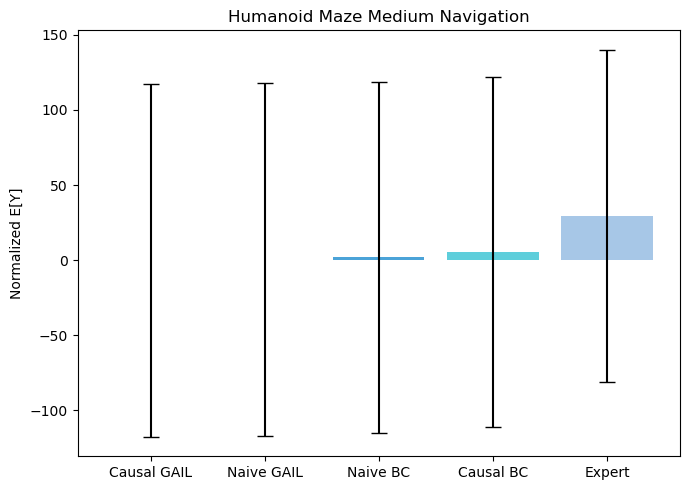

In [53]:
# compute averages
expert_avg = np.mean(expert_rewards)
causal_bc_avg = np.mean(causal_bc_rewards)
naive_bc_avg  = np.mean(naive_bc_rewards)
causal_gail_avg = np.mean(causal_gail_rewards)
naive_gail_avg  = np.mean(naive_gail_rewards)

# compute standard errors (optional but recommended)
expert_std = np.std(expert_rewards)
causal_bc_std = np.std(causal_bc_rewards)
naive_bc_std = np.std(naive_bc_rewards)
causal_gail_std = np.std(causal_gail_rewards)
naive_gail_std = np.std(naive_gail_rewards)

labels = ['Expert', 'Causal BC', 'Naive BC', 'Causal GAIL', 'Naive GAIL']
averages = [expert_avg, causal_bc_avg, naive_bc_avg, causal_gail_avg, naive_gail_avg]
errors = [expert_std, causal_bc_std, naive_bc_std, causal_gail_std, naive_gail_std]

# normalize results for better visualization
min_avg = min(averages)
averages = [avg - min_avg for avg in averages]

sorted_data = sorted(zip(averages, errors, labels), reverse=False)
averages, errors, labels = map(list, zip(*sorted_data))

colors = ['#0A5E8C',  # Expert
          '#4263EB',  # Causal BC
          '#4BA3D8',  # Naive BC
          '#5ECEDB',  # Causal GAIL
          '#A7C7E7']  # Naive GAIL

plt.figure(figsize=(7,5))
plt.bar(labels, averages, yerr=errors, capsize=6, color=colors)
plt.ylabel('Normalized E[Y]')
plt.title('Humanoid Maze Medium Navigation')
plt.tight_layout()
plt.show()

# Plots

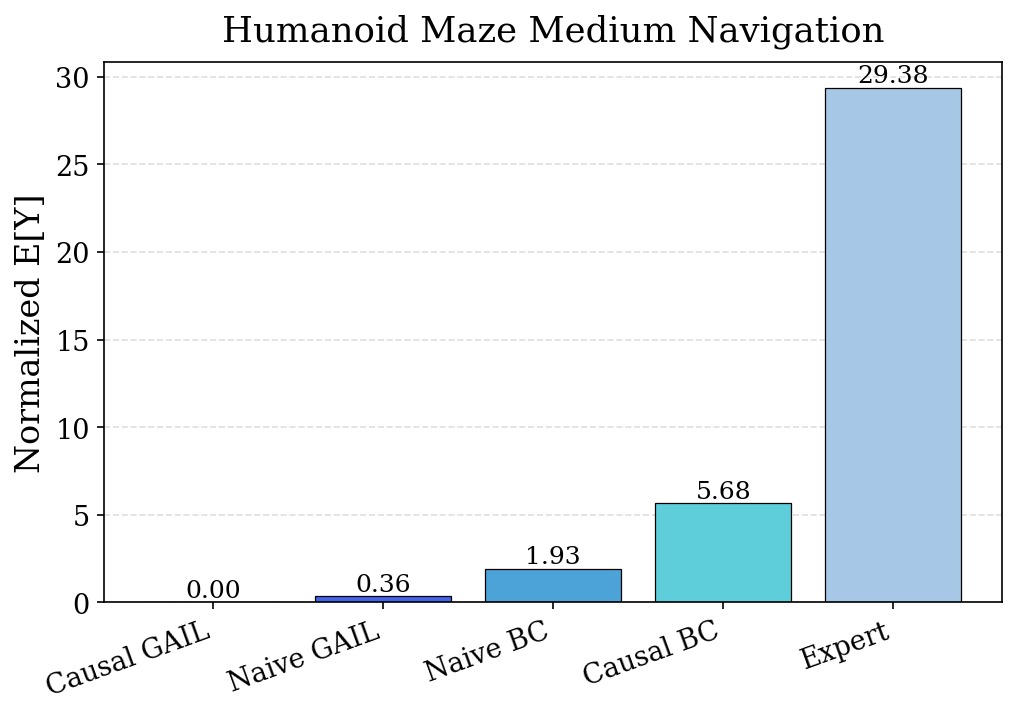

In [54]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.dpi": 150
})

# --- your data processing code here ---

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(labels, averages, capsize=4,
              color=colors, edgecolor="black", linewidth=0.6)

# subtle horizontal grid
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# labels
ax.set_ylabel("Normalized E[Y]", fontsize=16)
ax.set_title("Humanoid Maze Medium Navigation", fontsize=17, pad=10)

# rotate x-labels slightly for readability
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

# add numeric labels above bars (optional but nice)
for bar, avg in zip(bars, averages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
            f'{avg:.2f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('humanoidmaze_eval.pdf', dpi=300)
plt.show()

In [55]:
len(records), len(causal_bc_records), len(naive_bc_records), len(causal_gail_records), len(naive_gail_records)

(1999387, 2000000, 2000000, 2000000, 2000000)

In [56]:
sum(expert_rewards)/num_eps, sum(causal_bc_rewards)/num_eps, sum(naive_bc_rewards)/num_eps, sum(causal_gail_rewards)/num_eps, sum(naive_gail_rewards)/num_eps

(-345.951863850231,
 -369.648379982279,
 -373.40028284994577,
 -375.3295737874612,
 -374.9688936663899)

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import cm

def get_episode_xy_from_records(records, episode_id: int):
    '''
    records: list of dicts from collect_expert_trajectories(...)
    episode_id: which episode to extract

    Returns:
        xs, ys : np.ndarray of shape (T,)
    '''
    # Filter records for that episode, sorted by step
    ep = [r for r in records if r['episode'] == episode_id]
    ep = sorted(ep, key=lambda r: r['step'])

    xs, ys = [], []
    for r in ep:
        # r['info']['hidden_obs']['P'] is a *history* list; last entry is current position
        pos = r['obs']['P'][-1]   # shape (2,)
        xs.append(pos[0])
        ys.append(pos[1])

    return np.array(xs), np.array(ys)

def plot_humanoid_trajectory_xy(records, episode_id: int = 0, ax=None, title_prefix='HumanoidMaze'):
    '''
    Visualize the humanoid's 2D trajectory (x, y) for a single episode.

    - Path is colored by time (early=dark, late=bright).
    - Start and end are annotated.
    - Small arrows show direction every few steps.
    '''
    xs, ys = get_episode_xy_from_records(records, episode_id)
    T = len(xs)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    # Build a colored line collection for the path
    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Time as color (0..1)
    t_norm = np.linspace(0, 1, T-1)
    lc = LineCollection(segments, cmap='viridis', norm=plt.Normalize(0, 1))
    lc.set_array(t_norm)
    lc.set_linewidth(2.5)
    ax.add_collection(lc)

    # Start and end markers
    ax.scatter(xs[0], xs[0], alpha=0)  # dummy to keep colors aligned if needed
    ax.scatter(xs[0], ys[0], s=80, c='green', marker='o', edgecolors='black', label='Start')
    ax.scatter(xs[-1], ys[-1], s=80, c='red', marker='X', edgecolors='black', label='End')

    # Small arrows every N steps to show direction
    step = max(1, T // 30)  # about ~30 arrows max
    for i in range(0, T-1, step):
        dx = xs[i+1] - xs[i]
        dy = ys[i+1] - ys[i]
        ax.arrow(xs[i], ys[i], dx, dy,
                 length_includes_head=True,
                 head_width=0.2,
                 head_length=0.4,
                 alpha=0.6)

    # Colorbar for time
    cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Time (normalized)')

    ax.set_aspect('equal', 'box')
    ax.set_xlabel('x position')
    ax.set_ylabel('y position')
    ax.set_title(f'{title_prefix} - Episode {episode_id} trajectory')
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.savefig('humanoidmaze_causal_traj.pdf', dpi=300)
    return fig, ax

In [58]:
i = 0

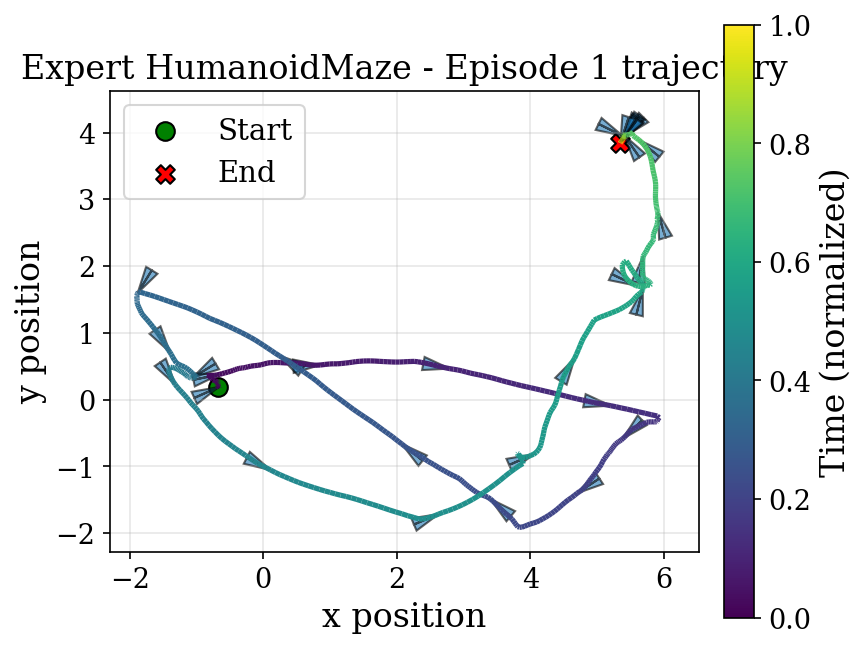

In [59]:
fig, ax = plot_humanoid_trajectory_xy(records, episode_id=1, title_prefix='Expert HumanoidMaze')
plt.show()
i += 1

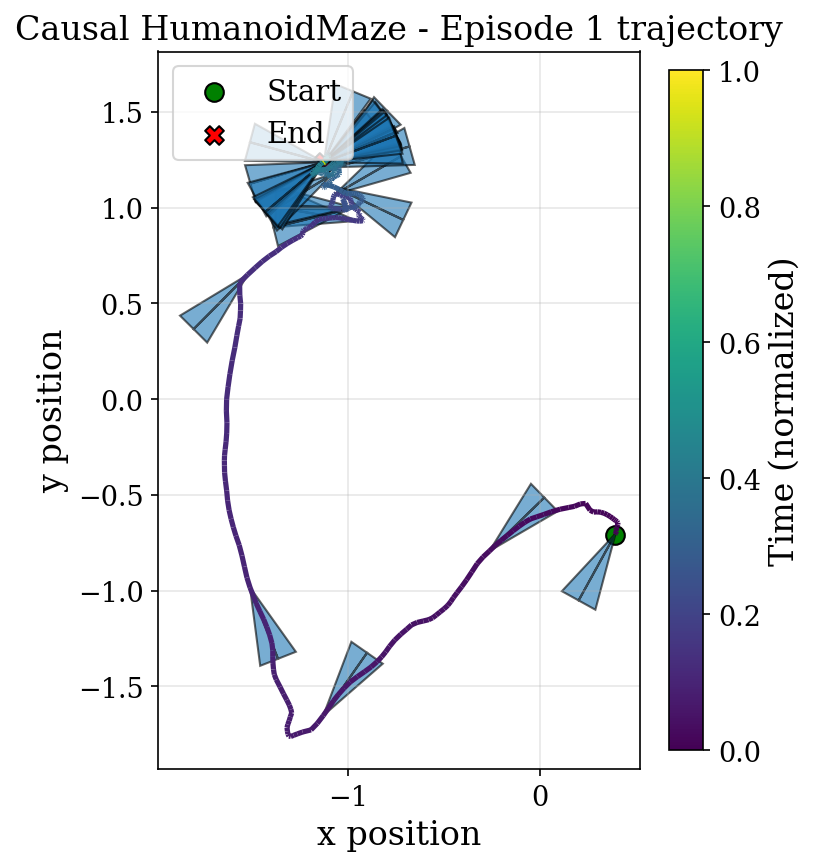

In [60]:
fig, ax = plot_humanoid_trajectory_xy(causal_bc_records, episode_id=i % num_eps, title_prefix='Causal HumanoidMaze')
plt.show()
i += 1

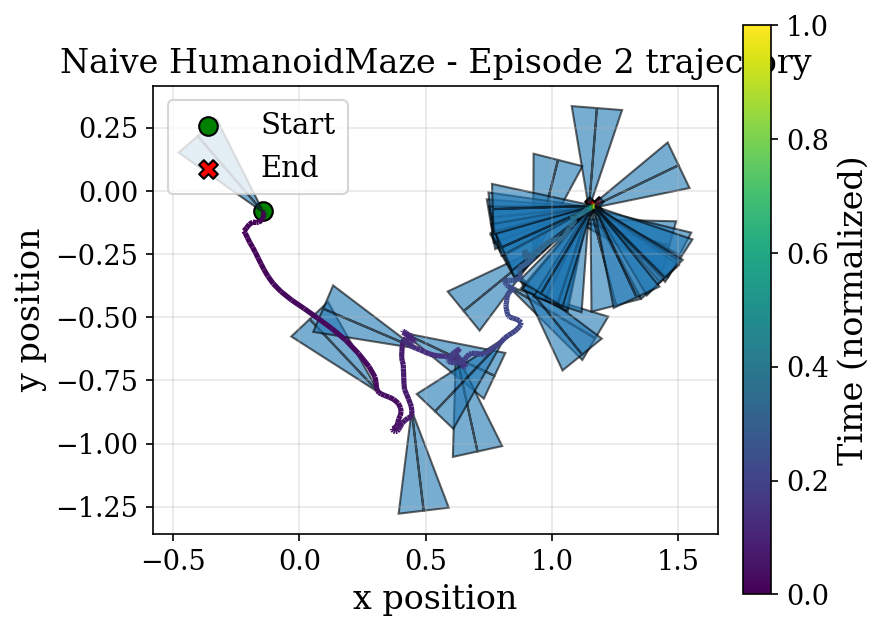

In [61]:
fig, ax = plot_humanoid_trajectory_xy(naive_bc_records, episode_id=i % num_eps, title_prefix='Naive HumanoidMaze')
plt.show()
i += 1

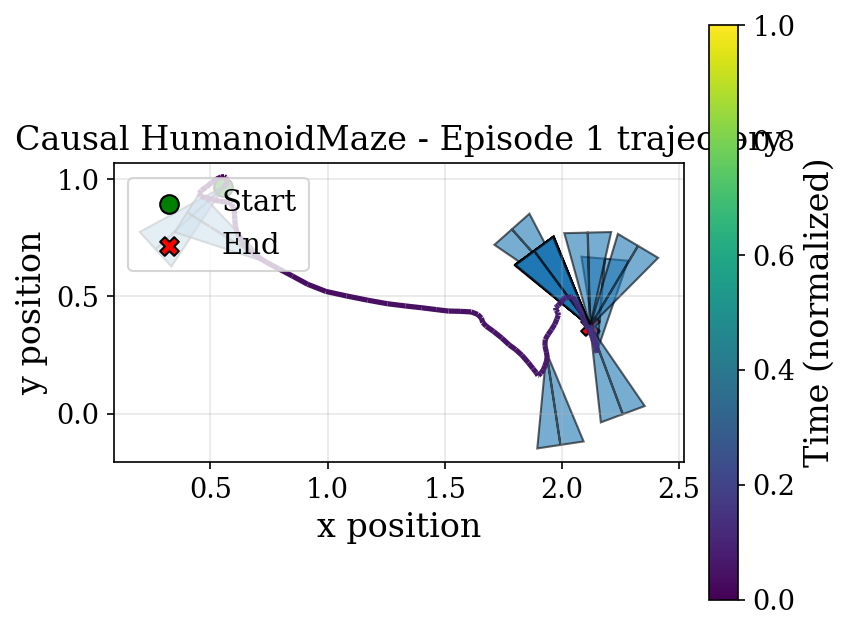

In [62]:
fig, ax = plot_humanoid_trajectory_xy(causal_gail_records, episode_id=1, title_prefix='Causal HumanoidMaze')
plt.show()
i += 1

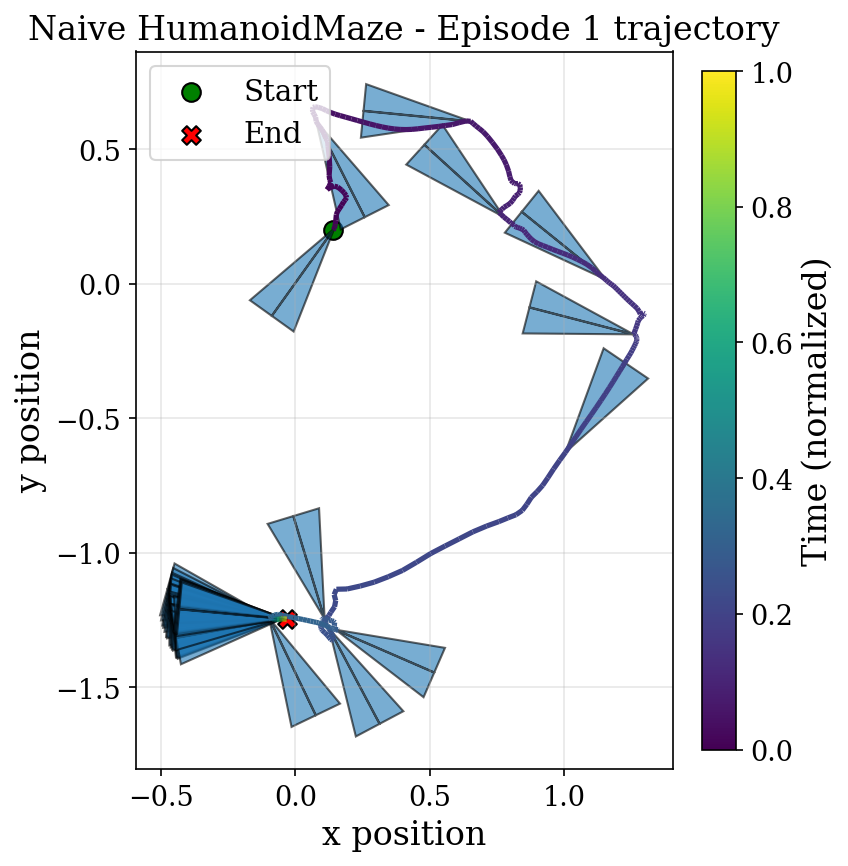

In [63]:
fig, ax = plot_humanoid_trajectory_xy(naive_gail_records, episode_id=1, title_prefix='Naive HumanoidMaze')
plt.show()
i += 1

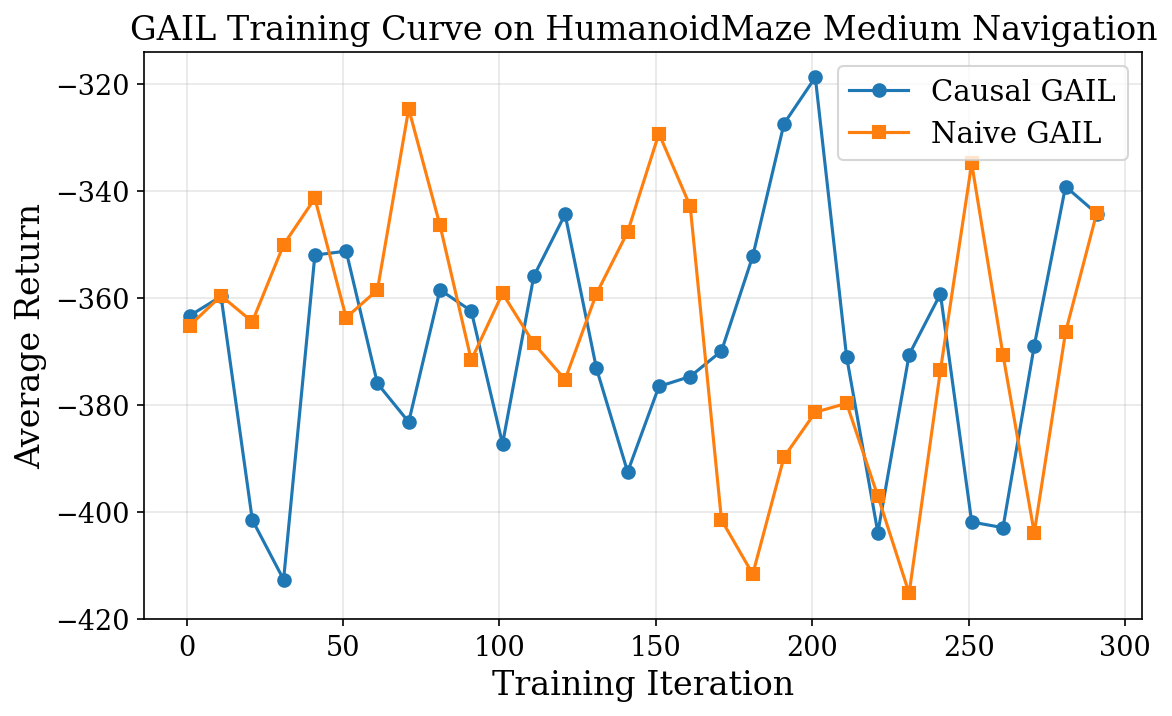

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# ---- 1) Naive GAIL returns ----
naive_returns_full = [entry["avg_env_return"] for entry in logs_naive_gail]
naive_iters = list(range(1, 301, 10))
naive_returns = [naive_returns_full[i - 1] for i in naive_iters]  # i-1 because 0-based

# ---- 2) Causal GAIL returns, subsampled every 10 iterations ----
# logs_causal_gail should have one entry per iter, in order: iter 1..N
causal_returns_full = [entry["avg_env_return"] for entry in logs_causal_gail]

causal_iters = naive_iters  # same x-axis points
causal_returns = [causal_returns_full[i - 1] for i in causal_iters]  # i-1 because 0-based

# ---- 3) Plot ----
plt.figure(figsize=(8, 5))
plt.plot(causal_iters, causal_returns, marker="o", label="Causal GAIL")
plt.plot(naive_iters, naive_returns, marker="s", label="Naive GAIL")

plt.xlabel("Training Iteration")
plt.ylabel("Average Return")
plt.title("GAIL Training Curve on HumanoidMaze Medium Navigation")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("humanoidmaze_gail_learning_curve_subsampled.pdf", dpi=300, bbox_inches="tight")
plt.show()

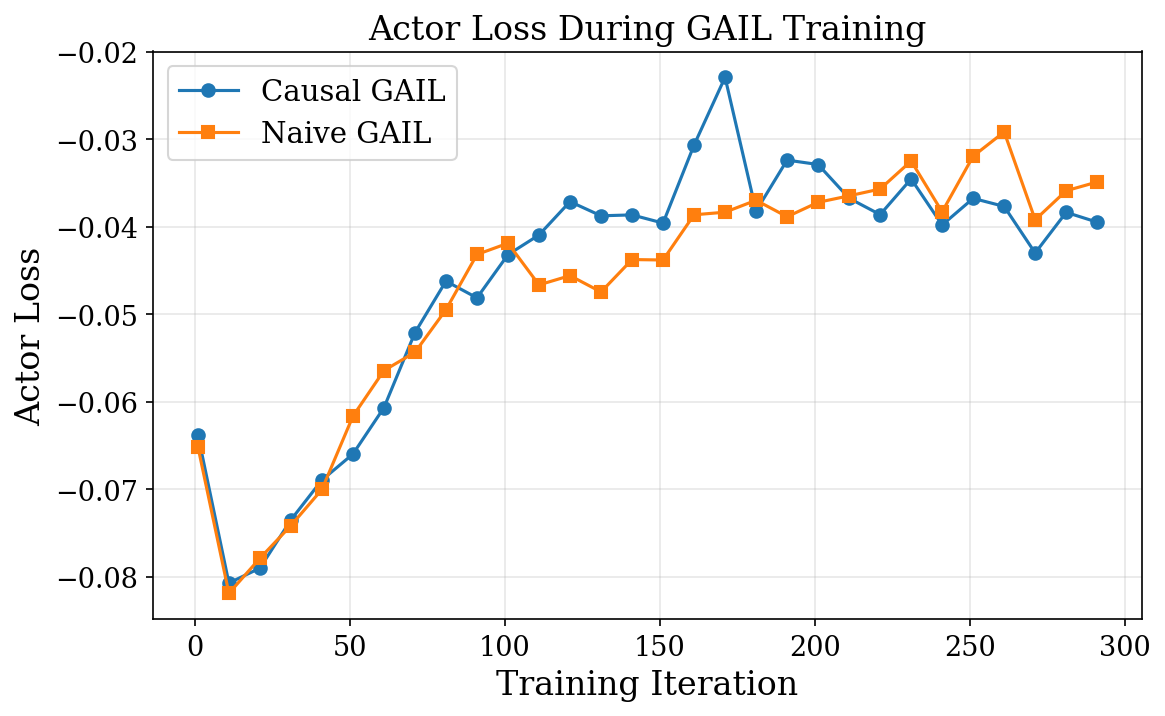

In [65]:
# ---- Naive GAIL actor losses from printouts ----
naive_actor_full = [x["ppo_actor_loss"] for x in logs_naive_gail]
naive_actor_losses = [naive_actor_full[i - 1] for i in naive_iters]

# ---- Causal GAIL actor loss: subsample every 10 iterations ----
causal_actor_full = [x["ppo_actor_loss"] for x in logs_causal_gail]
causal_actor_losses = [causal_actor_full[i - 1] for i in naive_iters]

# ---- Plot ----
plt.figure(figsize=(8, 5))
plt.plot(naive_iters, causal_actor_losses, marker="o", label="Causal GAIL")
plt.plot(naive_iters, naive_actor_losses, marker="s", label="Naive GAIL")

plt.xlabel("Training Iteration")
plt.ylabel("Actor Loss")
plt.title("Actor Loss During GAIL Training")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("humanoidmaze_actor_loss_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()


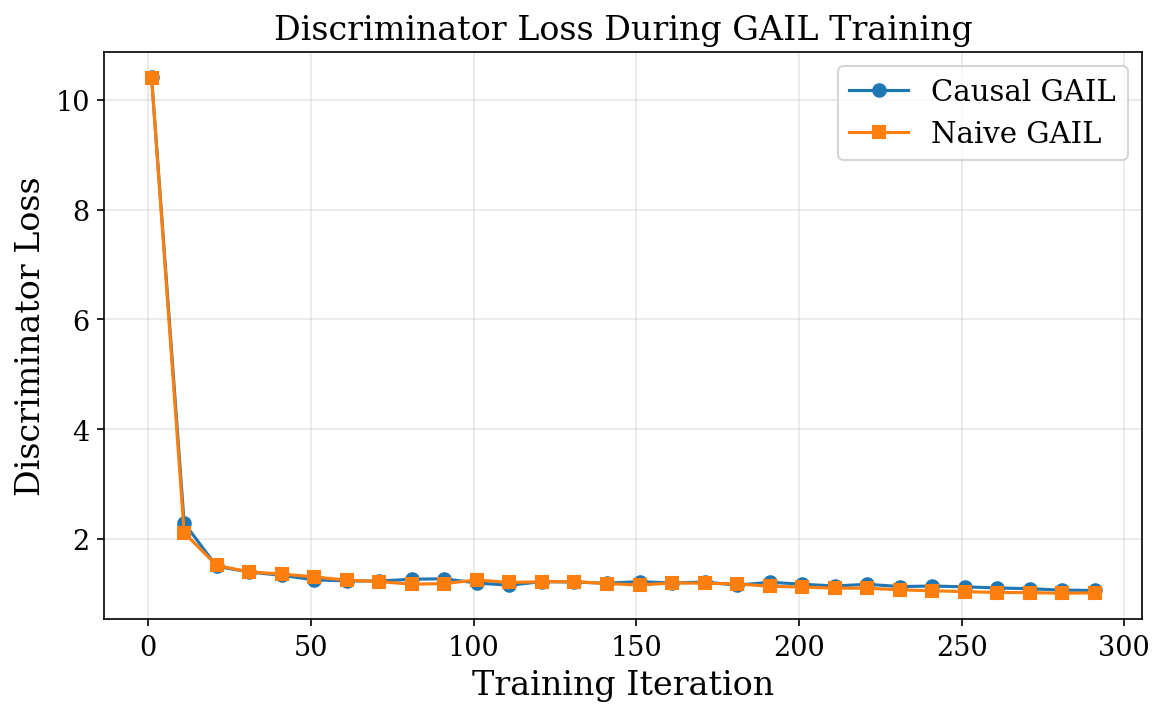

In [66]:
# ---- Naive GAIL discriminator losses from printouts ----
naive_d_full = [x["D_loss"] for x in logs_naive_gail]
naive_d_losses = [naive_d_full[i - 1] for i in naive_iters]

# ---- Causal GAIL D-loss: subsample ----
causal_d_full = [x["D_loss"] for x in logs_causal_gail]
causal_d_losses = [causal_d_full[i - 1] for i in naive_iters]

# ---- Plot ----
plt.figure(figsize=(8, 5))
plt.plot(naive_iters, causal_d_losses, marker="o", label="Causal GAIL")
plt.plot(naive_iters, naive_d_losses, marker="s", label="Naive GAIL")

plt.xlabel("Training Iteration")
plt.ylabel("Discriminator Loss")
plt.title("Discriminator Loss During GAIL Training")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("humanoidmaze_discriminator_loss_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

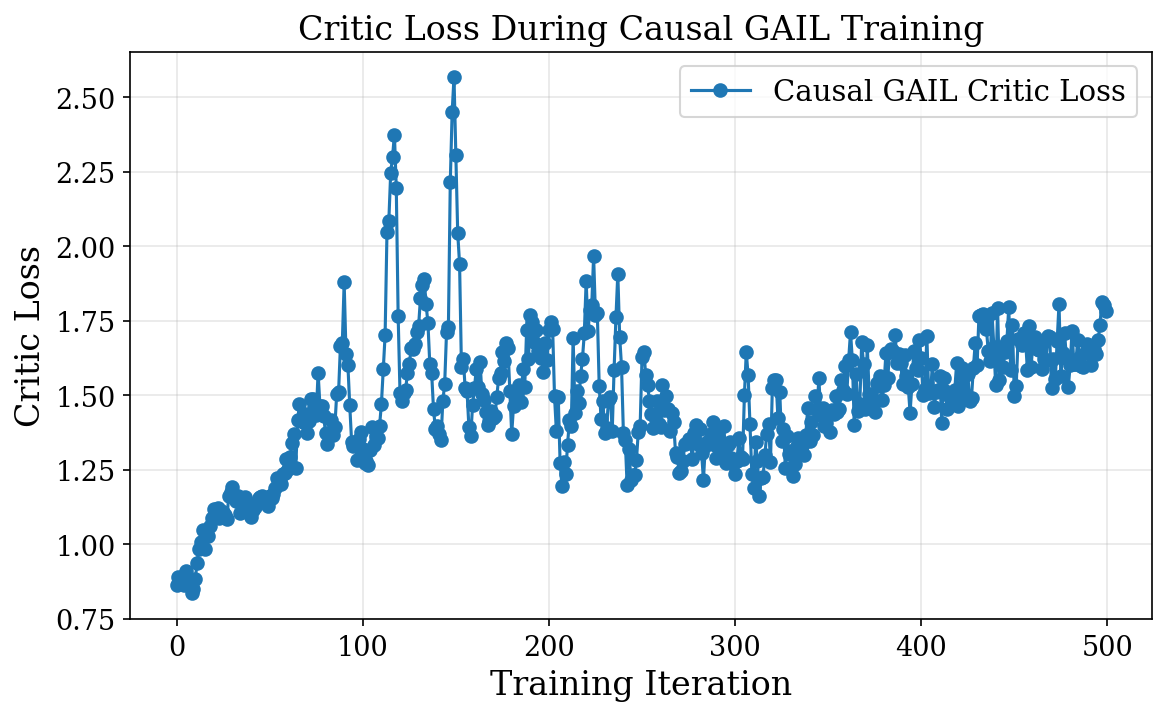

In [67]:
# ---- Causal GAIL Critic Loss ----
causal_critic_full = [x["ppo_critic_loss"] for x in logs_causal_gail]

plt.figure(figsize=(8, 5))
plt.plot(causal_critic_full, marker="o", label="Causal GAIL Critic Loss")
plt.xlabel("Training Iteration")
plt.ylabel("Critic Loss")
plt.title("Critic Loss During Causal GAIL Training")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("humanoidmaze_causal_critic_loss_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()


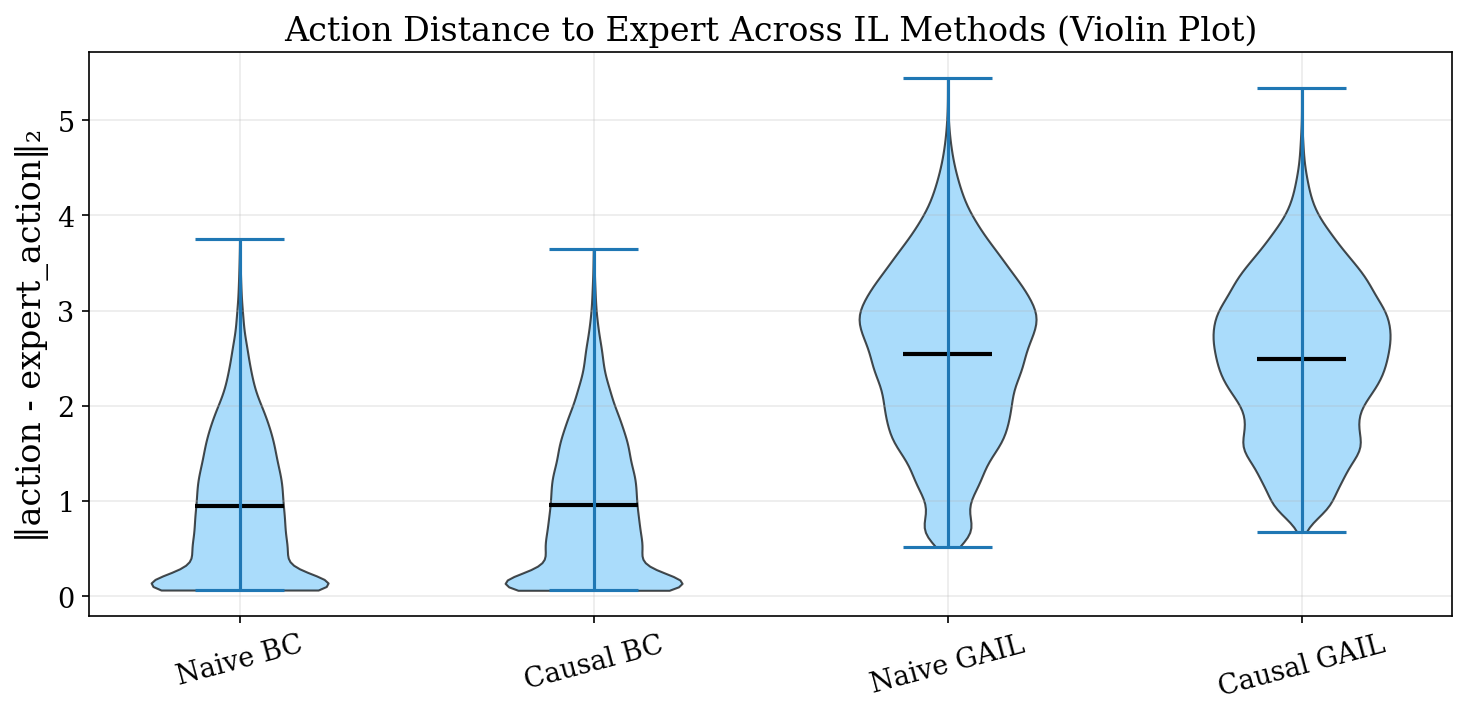

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# CONFIG
# ----------------------------------------
N_SAMPLES = 10000   # <- adjust depending on how fast you want it
np.random.seed(0)

# Sample a subset of indices
idxs = np.random.choice(len(records), size=min(N_SAMPLES, len(records)), replace=False)
records_sampled = [records[i] for i in idxs]

# ----------------------------------------
# Distance function
# ----------------------------------------
def action_distance(policy_fn, recs):
    diffs = []
    for rec in recs:
        obs = rec["obs"]
        a_exp = rec["action"].astype(np.float32)
        a_pi  = policy_fn(obs).astype(np.float32)
        diffs.append(np.linalg.norm(a_pi - a_exp))
    return np.array(diffs)

# ----------------------------------------
# Collect distances
# ----------------------------------------
d_naive_bc   = action_distance(naive_bc_policy, records_sampled)
d_causal_bc  = action_distance(causal_bc_policy, records_sampled)
d_naive_gail = action_distance(naive_gail_policy, records_sampled)
d_causal_gail= action_distance(causal_gail_policy, records_sampled)

data = [d_naive_bc, d_causal_bc, d_naive_gail, d_causal_gail]
labels = ["Naive BC", "Causal BC", "Naive GAIL", "Causal GAIL"]

# ----------------------------------------
# Violin plot
# ----------------------------------------
plt.figure(figsize=(10,5))
parts = plt.violinplot(
    data,
    showmeans=True,
    showextrema=True,
    showmedians=False
)

# Aesthetics
for pc in parts['bodies']:
    pc.set_facecolor("#87CEFA")
    pc.set_edgecolor("black")
    pc.set_alpha(0.7)

parts['cmeans'].set_edgecolor("black")
parts['cmeans'].set_linewidth(2)

plt.xticks(np.arange(1, len(labels)+1), labels, rotation=15)
plt.ylabel("‖action - expert_action‖₂")
plt.title("Action Distance to Expert Across IL Methods (Violin Plot)")
plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("humanoidmaze_action_distance_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_317685/1262858485.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True,


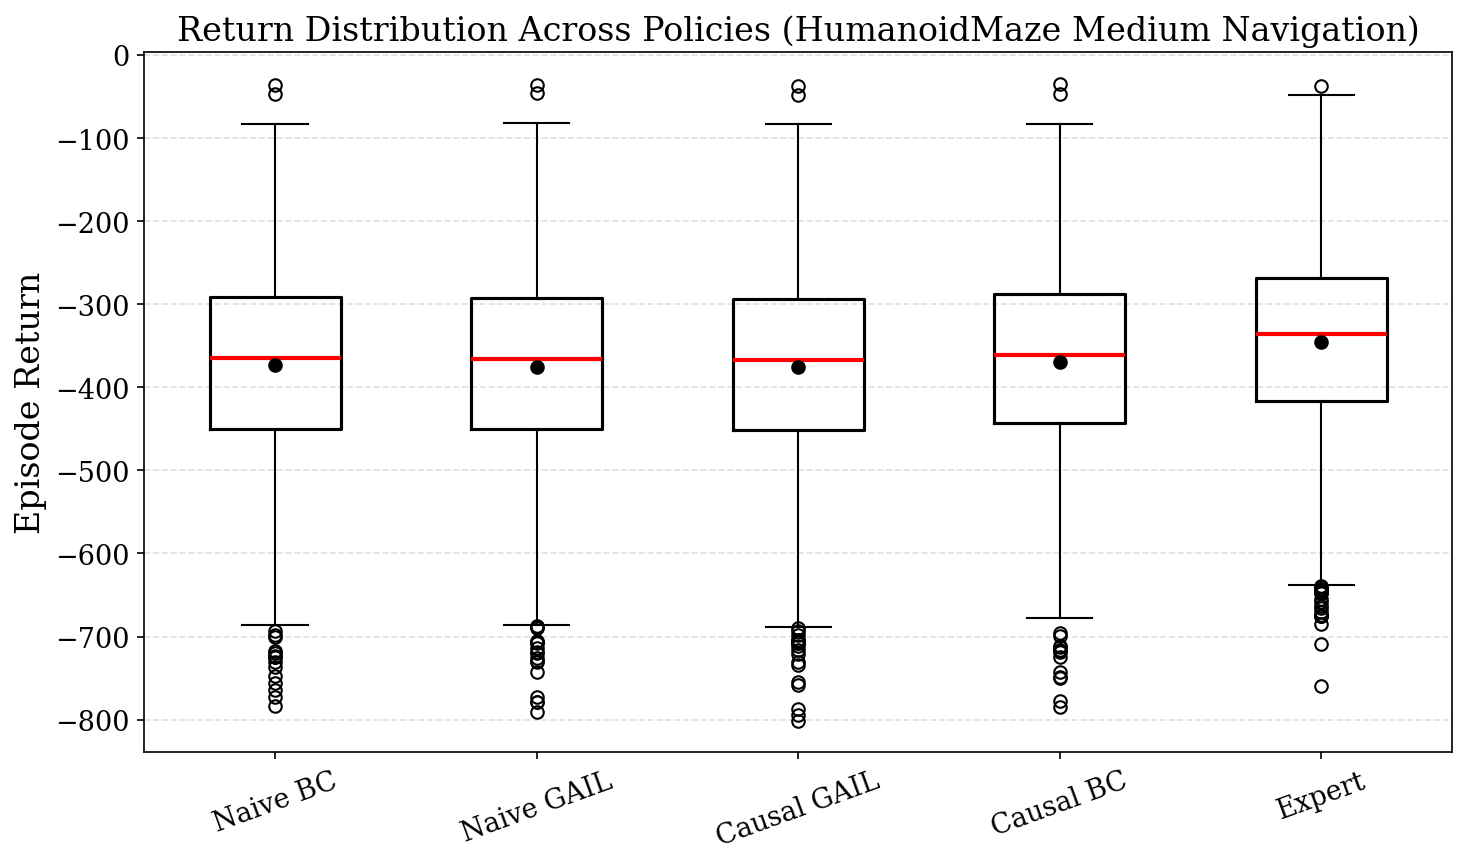

In [69]:
import matplotlib.pyplot as plt

labels = [
    "Naive BC",
    "Naive GAIL",
    "Causal GAIL",
    "Causal BC",
    "Expert"
]

data = [
    naive_bc_rewards,
    naive_gail_rewards,
    causal_gail_rewards,
    causal_bc_rewards,
    expert_rewards
]

plt.figure(figsize=(10,6))
plt.boxplot(data, labels=labels, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"black"},
            boxprops=dict(linewidth=1.5),
            medianprops=dict(linewidth=2, color="red"))

plt.ylabel("Episode Return")
plt.title("Return Distribution Across Policies (HumanoidMaze Medium Navigation)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("humanoidmaze_return_distribution.pdf", dpi=300)
plt.show()